# Figure05X — When Do Collapsing Bounds Help?

## Summary

In the pigeon task, the optimal decision boundary for an SNR-agnostic observer is **flat or
increasing**, not collapsing.  This holds for all three block reward structures and for the
actual pigeon-task SNR pair {μ=0.05, μ=0.15}.  However, adding even a small fraction of
**zero-SNR** (μ=0) trials to the mix causes collapsing bounds to become optimal.

### Why collapsing does NOT help for two non-zero SNRs

For block 2 the optimal flat bound is monotonically decreasing in μ: harder trials need a
higher position threshold to accumulate enough evidence.  The simulation confirms
b*(lo) > b*(hi).

An agnostic observer facing a mix sees hi-SNR trials exit quickly at their low optimal bound,
leaving an enriched pool of lo-SNR trials that need a *higher* bound.  The optimal agnostic
policy is therefore an **increasing** bound — start low to capture early hi-SNR exits, then
rise to handle the harder trials that persist.  A collapsing bound does exactly the opposite.

The effect is real but small.  For {μ=0.05, μ=0.15} in block 2, the best increasing bound
achieves RR = 0.12904 vs. the best flat bound at RR = 0.12853 (+0.4% relative), and the
best collapsing bound at RR = 0.12800 (−0.4% relative).  Flat, increasing, and collapsing
bounds all perform very similarly because the two SNR levels have only moderately different
FPT distributions (~2–3× ratio), providing weak temporal sorting.

### Why collapsing DOES help when zero-SNR is included

μ=0 trials are pure random walks with no drift — any response is correct or wrong with 50%
probability regardless of how long you wait.  For block 2, continued accumulation on a
zero-SNR trial is pure cost with no benefit.  Because the zero-drift random walk takes longer
to hit any bound than a drifting walk, these trials naturally **exit last**.  By the time a
late timepoint is reached, the surviving pool has been purified to mostly μ=0 trials.  The
optimal response at that point is to commit quickly — i.e., to use a low (collapsed) bound.

The effect is again modest.  For {μ=0, μ=0.05, μ=0.15} in block 2, the best collapsing
bound achieves RR = 0.00736 vs. the best flat bound at RR = 0.00707 (+4% relative).  This
is roughly 10× larger than the two-SNR increasing-bound advantage, because the μ=0 heavy
tail creates much stronger temporal sorting — but the overall RR values are tiny (the block
barely earns positive reward on average), so the absolute gain is small.

### When is a higher bound ever justified?

For any reward structure, using a higher bound is only worthwhile if the gain in accuracy
outweighs the cost of the additional decision time.  Formally: the bound should increase as
long as the marginal gain in P(correct) exceeds the marginal cost of the longer RT, scaled
by the reward rate.  For a discrete random walk in the noise-dominated regime (μ ≪ σ), RT
grows approximately as b²/σ² for small b, with a crossover toward the linear b/μ
(drift-dominated) scaling when b ≫ σ²/μ.  For the pigeon task (μ=0.05, σ=0.15), the
crossover occurs around b ≈ σ²/μ = 0.45, so most of the relevant bound range is
noise-dominated.  Meanwhile accuracy grows slowly (roughly as Φ evaluated at a quantity
proportional to √b), so the P(correct)/RT ratio declines as b increases beyond b*.  The
optimal bound is the peak of this trade-off.

### Connection to Drugowitsch et al. (2012)

Drugowitsch et al. showed that collapsing bounds are optimal when evidence strength varies
across trials (J. Neurosci. 32:3612–3628).  Their theoretical examples used a Gaussian prior
p(μ) = N(0, σ_μ²) centered at **zero** — a distribution with its peak density at μ=0 and
substantial mass near zero throughout.  Their empirical dataset also included explicit 0%
coherence trials.  The paper does not explicitly identify near-zero SNR as a *necessary*
condition, but our simulations confirm it is: restricting the prior to strictly non-zero SNRs
eliminates the collapsing advantage entirely.

**Two key differences from the pigeon task:**

*1. Explicit time cost.*  The Drugowitsch (2012) framework introduces a per-step cost of
accumulating evidence c(t) that rises over time (their Figure 3D).  This rising cost makes
early stopping increasingly attractive as a trial progresses, independently of the opportunity
cost captured by the time denominator of the reward-rate formula.  The pigeon task
simulations here have no such explicit cost — the only pressure to stop comes from the
opportunity cost of longer trials.  This is a weaker incentive to collapse the bound, which
is part of why the collapsing advantage is small (~4% relative) even in the three-SNR
condition.  Their reward structure also differs: Figure 3 uses +1 for correct and 0 for
errors ("no punishment for wrong choices"), whereas block 2 of the pigeon task uses +1/−4.

*2. Continuous vs. discrete diffusion.*  Drugowitsch uses continuous Brownian motion, where
P(correct | b → 0) → 0.5 exactly — responding immediately is indistinguishable from
guessing, so accumulation is always necessary to earn above-chance reward.  The pigeon task
uses a discrete random walk with step size σ = 0.15.  After just *one step*, the DV is
already informative:

$$P(\text{correct} \mid b \to 0) = \Phi\!\left(\frac{\mu}{\sigma}\right)$$

For lo-SNR this is Φ(0.33) ≈ 0.63; for hi-SNR it is Φ(1.0) ≈ 0.84.  Under block 1 rewards
(+1 correct, 0 error), a single step yields ~63% accuracy and the reward rate is already
maximised at b→0: 0.63/(1 + NDT).  Any larger bound increases RT faster than it increases
accuracy, so waiting is never worth it.  This is why block 1 gives b*→0 for all SNR levels —
a result with no analogue in the continuous diffusion setting.  Block 2's −4 penalty for
errors is what forces non-trivial optimal bounds in the pigeon task, by requiring
P(correct) > 0.80 before a trial earns positive expected reward at all.

## Simulations in this notebook

**Part 1 — Pigeon task, two non-zero SNRs, block 2** {μ = 0.05, μ = 0.15}
- Single-SNR RR curves showing b*(μ_lo) > b*(μ_hi) — the theoretical reason an agnostic observer needs an increasing bound
- Linear time-varying bound RR matrix confirming increasing is optimal, collapsing is suboptimal

**Part 2 — Adding zero-SNR** {μ = 0, μ = 0.05, μ = 0.15}, block 2
- Temporal sorting: first-passage time distributions showing μ=0 exits last
- Linear time-varying bound RR matrix showing collapsing becomes optimal once μ=0 is included

**Bound parameterisation used throughout:**

$$B(t) = B_\text{ini} + (B_\text{fin} - B_\text{ini}) \cdot \frac{\min(t,\; T_\text{change})}{T_\text{change}}$$

The (B_ini, B_fin) grid covers all cases on a single heatmap:
- **Diagonal** (B_fin = B_ini): flat bound
- **Below diagonal** (B_fin < B_ini): collapsing bound
- **Above diagonal** (B_fin > B_ini): increasing bound

In [7]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import ndtr as Phi   # standard normal CDF

# ── Task parameters ───────────────────────────────────────────────────────────
G_STD     = 0.15    # noise SD per step (shared across all SNR levels)
MAX_STEPS = 300     # trial hard cutoff; long enough that zero-SNR trials can accumulate
T_CHANGE  = 30      # number of steps over which the bound ramps from B_ini to B_fin
N_TRIALS  = 60_000  # trajectories per SNR level
ITI       = 0       # inter-trial interval (steps added to denominator of RR)

# Block 2: gain 1 coin for correct, lose 4 for incorrect
BD2 = dict(coins_gained=1, coins_lost=4)

# ── Bound grid ────────────────────────────────────────────────────────────────
# 20 evenly-spaced values; both B_ini and B_fin are drawn from this set,
# giving a 20×20 grid of (initial, final) bound combinations.
RR_BOUNDS = np.arange(0.01, 0.81, 0.04)
n = len(RR_BOUNDS)

# ── Masks for the RR matrix ───────────────────────────────────────────────────
# The matrix is stored as rr_matrix[fin_idx, ini_idx].
# With imshow(origin='lower'): columns = ini_idx (x-axis), rows = fin_idx (y-axis).
# Diagonal (fin == ini):          flat bound
# Upper-left  (fin_idx > ini_idx, B_fin > B_ini): increasing — above the diagonal in plot
# Lower-right (fin_idx < ini_idx, B_fin < B_ini): collapsing — below the diagonal in plot
#
# In the numpy array (without imshow flip):
#   triu(k=1): col > row → ini_idx > fin_idx → B_ini > B_fin → collapsing
#   tril(k=-1): row > col → fin_idx > ini_idx → B_fin > B_ini → increasing
COLL_MASK = np.triu(np.ones((n, n), bool), k=1)
INCR_MASK = np.tril(np.ones((n, n), bool), k=-1)

rng = np.random.default_rng(42)

# ── Discrete-walk sanity check ────────────────────────────────────────────────
# For continuous Brownian motion, P(correct | b→0) → 0.5.
# For a discrete walk with step size σ, the first step already carries signal:
#   P(correct | b→0) → Φ(μ/σ)
# This determines whether a break-even bound exists at all.
for mu, label in [(0.05, 'lo SNR'), (0.15, 'hi SNR')]:
    p0 = Phi(mu / G_STD)
    print(f"{label} (μ={mu}):  P(correct | b→0) = Φ({mu/G_STD:.2f}) ≈ {p0:.3f}"
          f"  {'> 0.80 → no break-even bound' if p0 > 0.8 else '< 0.80 → break-even exists'}")

lo SNR (μ=0.05):  P(correct | b→0) = Φ(0.33) ≈ 0.631  < 0.80 → break-even exists
hi SNR (μ=0.15):  P(correct | b→0) = Φ(1.00) ≈ 0.841  > 0.80 → no break-even bound


In [ ]:
print("Generating trajectories (one set reused across all simulations)...")
trajs = {}   # trajs[mu] → (N_TRIALS, MAX_STEPS+1) float32 array of cumulative DV paths
ndts  = {}   # ndts[mu]  → (N_TRIALS,) int array of non-decision times (0 or 1 step each)

for mu in [0.0, 0.05, 0.15]:
    # Draw MAX_STEPS Gaussian steps per trial, then prepend a column of zeros (DV starts at 0)
    noise = rng.normal(mu, G_STD, (N_TRIALS, MAX_STEPS))
    DV = np.concatenate(
        [np.zeros((N_TRIALS, 1)), np.cumsum(noise, axis=1)], axis=1
    ).astype(np.float32)   # float32 halves memory without meaningful precision loss
    trajs[mu] = DV
    ndts[mu]  = rng.integers(0, 2, N_TRIALS)   # uniform NDT ∈ {0, 1} steps
    print(f"  μ={mu:.2f}  {N_TRIALS:,} trials  ({DV.nbytes/1e6:.0f} MB)")


def compute_rr_matrix(mu_list, bd=BD2, iti=ITI):
    """Compute the (B_ini, B_fin) reward-rate matrix for a set of SNR levels.

    All SNR levels in mu_list share the same time-varying bound on every trial.
    Returns rr_matrix[fin_idx, ini_idx] — see mask comments in setup cell.
    """
    t  = np.arange(MAX_STEPS, dtype=np.float32)
    rm = np.zeros((n, n))

    for ini_idx, B_ini in enumerate(RR_BOUNDS):
        for fin_idx, B_fin in enumerate(RR_BOUNDS):
            # Build the bound trajectory B(t) for this (B_ini, B_fin) pair.
            # frac goes 0→1 over the first T_CHANGE steps, then stays at 1.
            frac = np.minimum(t, T_CHANGE) / T_CHANGE
            B_t  = B_ini + (B_fin - B_ini) * frac   # shape (MAX_STEPS,)

            tc, ts = 0.0, 0.0   # total coins and total steps across all SNR levels

            for mu in mu_list:
                DV, ndt = trajs[mu], ndts[mu]
                N = len(ndt)

                # Find first time |DV| ≥ B_t for each trial.
                # DV[:,1:] skips the t=0 column (DV is 0 there by construction).
                crossed = np.abs(DV[:, 1:]) >= B_t[None, :]   # (N, MAX_STEPS) bool
                any_c   = crossed.any(axis=1)                  # (N,) — did the trial ever cross?

                # argmax returns the index of the first True; if never crossed, use MAX_STEPS.
                # +1 converts from 0-indexed column to 1-indexed step number.
                si = np.where(any_c, np.argmax(crossed, axis=1) + 1, MAX_STEPS)

                # Classify each trial: correct if DV is positive at the stopping step.
                # For bound crossings this is the crossing side; for timeouts it's the
                # final DV sign (which skews correct for drifting walks over long trials).
                correct = DV[np.arange(N), si] > 0

                coins = np.where(correct, bd['coins_gained'], -bd['coins_lost'])
                tc += coins.sum()
                ts += (si + ndt + iti + 1).sum()   # RT = si + NDT + ITI + 1 (matches simulate_trials)

            rm[fin_idx, ini_idx] = tc / ts   # reward rate = coins per step
    return rm


def summarise(rm):
    """Return key statistics from a reward-rate matrix."""
    flat = max(rm[i, i] for i in range(n))       # best reward rate on the diagonal
    coll = rm[COLL_MASK].max()                    # best collapsing bound
    incr = rm[INCR_MASK].max()                    # best increasing bound
    bf, bi = np.unravel_index(rm.argmax(), rm.shape)
    Bi, Bf = RR_BOUNDS[bi], RR_BOUNDS[bf]
    kind = ('coll' if Bf < Bi - 1e-9 else
            'incr' if Bf > Bi + 1e-9 else 'flat')
    fi = np.argmax([rm[i, i] for i in range(n)])
    return flat, coll, incr, RR_BOUNDS[fi], Bi, Bf, kind

---
## Part 1 — Pigeon task: why collapsing bounds do not help

### The single-SNR optimal bound

For block 2 a trial earns positive expected reward only if:

$$P(\text{correct}) \cdot 1 - P(\text{incorrect}) \cdot 4 > 0 \;\Rightarrow\; P(\text{correct}) > \tfrac{4}{5} = 0.80$$

For **continuous Brownian motion** (infinitesimal step size), the accuracy at a flat bound
$b$ is the logistic of the LLR:

$$P_\text{BM}(\text{correct} \mid b) = \frac{1}{1 + e^{-2b\mu/\sigma^2}}$$

Setting this to 0.80 gives a tidy closed-form break-even bound:

$$b_\text{BE}^\text{BM}(\mu) = \frac{\log 4 \cdot \sigma^2}{2\mu}$$

**However, this formula does not apply to the pigeon task's discrete random walk.**

In a discrete walk with step size $\sigma = 0.15$, the DV at any crossing overshoots the
bound — the process jumps past $b$ rather than arriving exactly at it.  More fundamentally,
as $b \to 0$ the accuracy does not approach 0.5 but instead:

$$P(\text{correct} \mid b \to 0) \;\to\; \Phi\!\left(\frac{\mu}{\sigma}\right)$$

For hi-SNR: $\Phi(0.15/0.15) = \Phi(1) \approx 0.84 > 0.80$, so every bound is already
above break-even — there is no zero-crossing.  For lo-SNR: $\Phi(0.05/0.15) \approx 0.63$,
so a break-even bound exists but at $b \approx 0.20$, not 0.31.

The actual break-even and the actual optimal $b^*$ are found directly from the simulated
RR curve.  What matters for the argument below is that the simulation confirms
$b^*(\text{lo}) > b^*(\text{hi})$, so the agnostic bound must increase over time.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = {0.05: 'steelblue', 0.15: 'darkorange'}
labels = {0.05: 'lo SNR  (μ=0.05)', 0.15: 'hi SNR  (μ=0.15)'}
b_stars_emp = {}   # will hold the empirical optimal bound for each SNR

# ── Left panel: RR vs. flat bound, each SNR in isolation ─────────────────────
for mu in [0.05, 0.15]:
    DV, ndt = trajs[mu], ndts[mu]
    N = len(ndt)
    rr_vals = []

    for b in RR_BOUNDS:
        # Find first crossing of ±b for each trial
        crossed = np.abs(DV[:, 1:]) >= b
        any_c   = crossed.any(axis=1)
        si      = np.where(any_c, np.argmax(crossed, axis=1) + 1, MAX_STEPS)
        correct = DV[np.arange(N), si] > 0
        coins   = np.where(correct, BD2['coins_gained'], -BD2['coins_lost'])
        # RR for this single SNR level at this flat bound (no ITI here)
        # +1 matches simulate_trials convention: RT = si + ndt + 1
        rr_vals.append(coins.sum() / (si + ndt + 1).sum())

    rr_vals = np.array(rr_vals)
    b_opt = RR_BOUNDS[np.argmax(rr_vals)]   # bound that maximises RR for this SNR
    b_stars_emp[mu] = b_opt

    axes[0].plot(RR_BOUNDS, rr_vals, color=colors[mu], lw=2.2,
                 label=f'{labels[mu]}  (b* = {b_opt:.2f})')
    axes[0].axvline(b_opt, color=colors[mu], ls='--', lw=1.2, alpha=0.8)

# RR=0 line marks the break-even accuracy P(correct)=0.80 for block 2.
# hi-SNR never crosses it because Φ(μ/σ)=Φ(1)≈0.84 already at b→0.
axes[0].axhline(0, color='gray', ls=':', lw=0.9, label='RR = 0')
axes[0].set_xlabel('Flat bound (position units)', fontsize=11)
axes[0].set_ylabel('Reward rate  (coins / step)', fontsize=11)
axes[0].set_title('Single-SNR reward rate vs. bound\n(block 2, each SNR in isolation)',
                  fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Right panel: b* comparison bar chart ─────────────────────────────────────
# The key point: b*(lo) > b*(hi), so the agnostic observer needs an increasing bound.
x = np.arange(2)
mus_plot = [0.05, 0.15]
axes[1].bar(x, [b_stars_emp[m] for m in mus_plot],
            color=[colors[m] for m in mus_plot], alpha=0.85, width=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['lo SNR\n(μ=0.05)', 'hi SNR\n(μ=0.15)'], fontsize=11)
axes[1].set_ylabel('Optimal flat bound  b*', fontsize=11)
axes[1].set_title(f'b*(lo) = {b_stars_emp[0.05]:.2f},  b*(hi) = {b_stars_emp[0.15]:.2f}\n'
                  f'b*(lo) / b*(hi) = {b_stars_emp[0.05]/b_stars_emp[0.15]:.1f}×  '
                  f'→ agnostic bound must increase', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

# Annotate bar heights
for xi, mu in zip(x, mus_plot):
    axes[1].text(xi, b_stars_emp[mu] + 0.005, f'{b_stars_emp[mu]:.2f}',
                 ha='center', va='bottom', fontsize=11, color=colors[mu])

plt.tight_layout()
plt.show()
print(f"Empirical b*:  μ=0.05 → {b_stars_emp[0.05]:.3f},  μ=0.15 → {b_stars_emp[0.15]:.3f}")
print(f"Note: hi-SNR RR > 0 at all bounds (Φ(μ/σ)=Φ(1)≈0.84 > 0.80 already at b→0)")

### Simulation: agnostic linear bound over the full (B_ini, B_fin) grid

Each cell in the heatmap below is the reward rate for a single agnostic observer who uses a
linearly varying bound with the given initial and final values.  The diagonal is the flat
bound; the lower-right triangle is collapsing; the upper-left triangle is increasing.

The red star marks the global optimum.  The black dots mark all (B_ini, B_fin) pairs within
2% of the maximum reward rate.

Computing RR matrix: {μ=0.05, μ=0.15}, block 2…

  flat opt:  RR = 0.12853  (b = 0.25)
  coll best: RR = 0.12800  Δ = -0.00053
  incr best: RR = 0.12904  Δ = +0.00051
  global best: incr  B_ini=0.25 → B_fin=0.33


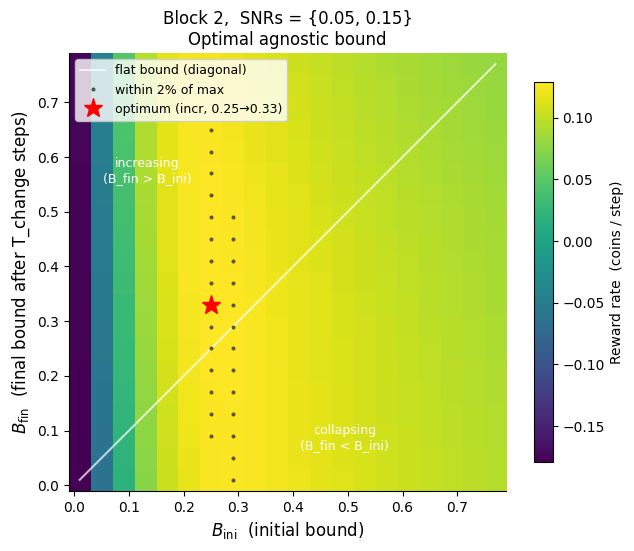

In [10]:
print("Computing RR matrix: {μ=0.05, μ=0.15}, block 2…")
rm_nozero = compute_rr_matrix([0.05, 0.15])
flat, coll, incr, b_flat, Bi, Bf, kind = summarise(rm_nozero)

print(f"\n  flat opt:  RR = {flat:.5f}  (b = {b_flat:.2f})")
print(f"  coll best: RR = {coll:.5f}  Δ = {coll-flat:+.5f}")
print(f"  incr best: RR = {incr:.5f}  Δ = {incr-flat:+.5f}")
print(f"  global best: {kind}  B_ini={Bi:.2f} → B_fin={Bf:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))

# imshow maps the matrix so columns = ini_idx (x-axis) and rows = fin_idx (y-axis).
# origin='lower' puts row 0 at the bottom, so the diagonal runs lower-left to upper-right.
half = (RR_BOUNDS[1] - RR_BOUNDS[0]) / 2
extent = [RR_BOUNDS[0]-half, RR_BOUNDS[-1]+half,
          RR_BOUNDS[0]-half, RR_BOUNDS[-1]+half]

im = ax.imshow(rm_nozero, origin='lower', extent=extent, aspect='equal', cmap='viridis')
plt.colorbar(im, ax=ax, label='Reward rate  (coins / step)', shrink=0.85)

# Diagonal = flat bound (B_ini = B_fin)
ax.plot([RR_BOUNDS[0], RR_BOUNDS[-1]], [RR_BOUNDS[0], RR_BOUNDS[-1]],
        'w-', lw=1.5, alpha=0.7, label='flat bound (diagonal)')

# Mark all (B_ini, B_fin) within 2% of the global maximum
near_opt = rm_nozero >= 0.98 * rm_nozero.max()
fi_idx, ii_idx = np.where(near_opt)
ax.plot(RR_BOUNDS[ii_idx], RR_BOUNDS[fi_idx], 'k.', ms=4, alpha=0.5,
        label='within 2% of max')

# Global optimum
bf_idx, bi_idx = np.unravel_index(rm_nozero.argmax(), rm_nozero.shape)
ax.plot(RR_BOUNDS[bi_idx], RR_BOUNDS[bf_idx], 'r*', ms=14, zorder=5,
        label=f'optimum ({kind}, {Bi:.2f}→{Bf:.2f})')

# Region labels: below diagonal = collapsing, above = increasing
ax.text(0.63, 0.12, 'collapsing\n(B_fin < B_ini)', transform=ax.transAxes,
        color='white', fontsize=9, ha='center', va='center')
ax.text(0.18, 0.73, 'increasing\n(B_fin > B_ini)', transform=ax.transAxes,
        color='white', fontsize=9, ha='center', va='center')

ax.set_xlabel('$B_\\mathrm{ini}$  (initial bound)', fontsize=12)
ax.set_ylabel('$B_\\mathrm{fin}$  (final bound after T_change steps)', fontsize=12)
ax.set_title('Block 2,  SNRs = {0.05, 0.15}\nOptimal agnostic bound', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Part 2 — Adding zero-SNR: why collapsing becomes optimal

### The temporal sorting mechanism

For collapsing to be beneficial, the pool of surviving (undecided) trials must shift toward
*harder* trials over time — so that a lower bound becomes appropriate at later timepoints.
This requires that easy trials exit faster than hard ones.

The strength of this sorting depends on how different the first-passage-time (FPT)
distributions are across SNR levels.  For a Gaussian random walk with drift μ and noise σ:

- **Drift-dominated** (μ >> σ): FPT ≈ b/μ, strongly dependent on μ → large FPT ratio
- **Noise-dominated** (μ << σ): FPT ≈ (b/σ)², weakly dependent on μ → small FPT ratio

The pigeon task has σ=0.15 and μ ∈ {0.05, 0.15}, so both SNR levels are in the
noise-dominated regime.  The FPT ratio between lo and hi SNR is only about 2–3×, providing
weak temporal sorting.  This is why an increasing bound (not collapsing) is optimal: even
though easy trials exit slightly first, the difference is too small to justify the cost of
lowering the bound for the remaining pool.

**Adding μ=0 changes this fundamentally.**  A pure random walk (zero drift) has
FPT ≈ (b/σ)², which for b=0.33 gives ~8 steps.  By contrast, the hi-SNR walk exits in
~3 steps.  More critically, the zero-drift walk has *no upper limit* on how long it can
take — its FPT distribution has a heavy tail.  At late timepoints, the surviving pool is
overwhelmingly composed of μ=0 trials.  Continued accumulation on those trials has zero
expected benefit (any response is 50/50), so the rational response is to commit immediately
— i.e., use a low (collapsed) bound.

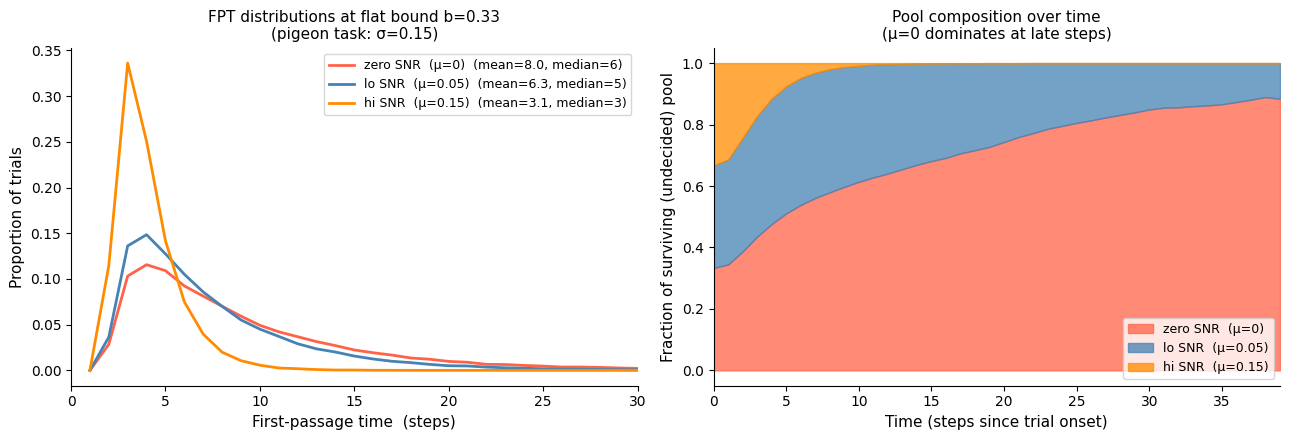


FPT summary at b=0.33:
  μ=0.00:  mean=8.0  median=6  P(exit by step 5)=0.449  P(exit by step 20)=0.949
  μ=0.05:  mean=6.3  median=5  P(exit by step 5)=0.554  P(exit by step 20)=0.982
  μ=0.15:  mean=3.1  median=3  P(exit by step 5)=0.918  P(exit by step 20)=1.000


In [11]:
b_ref = 0.33   # reference flat bound for illustrating FPT distributions

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mu_colors = {0.0: 'tomato', 0.05: 'steelblue', 0.15: 'darkorange'}
mu_labels = {0.0: 'zero SNR  (μ=0)', 0.05: 'lo SNR  (μ=0.05)', 0.15: 'hi SNR  (μ=0.15)'}

fpt_stats = {}   # will hold the per-trial FPT arrays for each SNR

# ── Left panel: FPT distributions ────────────────────────────────────────────
bins = np.arange(0, 51) - 0.5   # bin edges centred on integers 0..50

for mu in [0.0, 0.05, 0.15]:
    DV = trajs[mu]
    crossed = np.abs(DV[:, 1:]) >= b_ref
    any_c   = crossed.any(axis=1)
    # si: first-passage time in steps (MAX_STEPS for trials that never cross b_ref)
    si = np.where(any_c, np.argmax(crossed, axis=1) + 1, MAX_STEPS)
    fpt_stats[mu] = si

    # Histogram over the first 50 steps; normalise by total N to get proportions
    counts, _ = np.histogram(si[si <= 50], bins=bins, density=False)
    axes[0].plot(np.arange(1, 51), counts / len(si),
                 color=mu_colors[mu], lw=2,
                 label=f'{mu_labels[mu]}  (mean={si.mean():.1f}, median={np.median(si):.0f})')

axes[0].set_xlim(0, 30)
axes[0].set_xlabel('First-passage time  (steps)', fontsize=11)
axes[0].set_ylabel('Proportion of trials', fontsize=11)
axes[0].set_title(f'FPT distributions at flat bound b={b_ref}\n'
                  f'(pigeon task: σ={G_STD})', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Right panel: pool composition over time ───────────────────────────────────
# At each time step t, the "surviving pool" is trials that haven't yet crossed b_ref.
# We track what fraction of that pool belongs to each SNR level.
# This shows the temporal sorting mechanism: hi-SNR exits first, then lo-SNR,
# leaving zero-SNR trials increasingly dominant at late time points.
max_t = 40
surviving = {mu: np.zeros(max_t) for mu in [0.0, 0.05, 0.15]}
for mu in [0.0, 0.05, 0.15]:
    si = fpt_stats[mu]
    for t in range(max_t):
        surviving[mu][t] = (si > t).mean()   # fraction not yet decided by step t

# Normalise each time point so fractions sum to 1 across SNR levels
total_surviving = sum(surviving[mu] for mu in [0.0, 0.05, 0.15])
bottom = np.zeros(max_t)
t_axis = np.arange(max_t)

for mu in [0.0, 0.05, 0.15]:
    frac = surviving[mu] / np.maximum(total_surviving, 1e-9)   # guard against /0 at late t
    axes[1].fill_between(t_axis, bottom, bottom + frac,
                         color=mu_colors[mu], alpha=0.75, label=mu_labels[mu])
    bottom = bottom + frac   # stack the next SNR level on top

axes[1].set_xlabel('Time (steps since trial onset)', fontsize=11)
axes[1].set_ylabel('Fraction of surviving (undecided) pool', fontsize=11)
axes[1].set_title('Pool composition over time\n(μ=0 dominates at late steps)', fontsize=11)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_xlim(0, max_t - 1)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nFPT summary at b={b_ref}:")
for mu in [0.0, 0.05, 0.15]:
    si = fpt_stats[mu]
    print(f"  μ={mu:.2f}:  mean={si.mean():.1f}  median={np.median(si):.0f}"
          f"  P(exit by step 5)={( si<=5).mean():.3f}"
          f"  P(exit by step 20)={(si<=20).mean():.3f}")

### Simulation: agnostic linear bound with zero-SNR included

Same (B_ini, B_fin) grid search as Part 1, now pooling μ ∈ {0, 0.05, 0.15}.  The right
panel directly compares the best reward rates across bound types for both the two-SNR and
three-SNR conditions.

Computing RR matrix: {μ=0, μ=0.05, μ=0.15}, block 2…

  flat opt:  RR = 0.00707  (b = 0.65)
  coll best: RR = 0.00736  Δ = +0.00029
  incr best: RR = 0.00698  Δ = -0.00008
  global best: coll  B_ini=0.77 → B_fin=0.45


/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_96881/2845045584.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


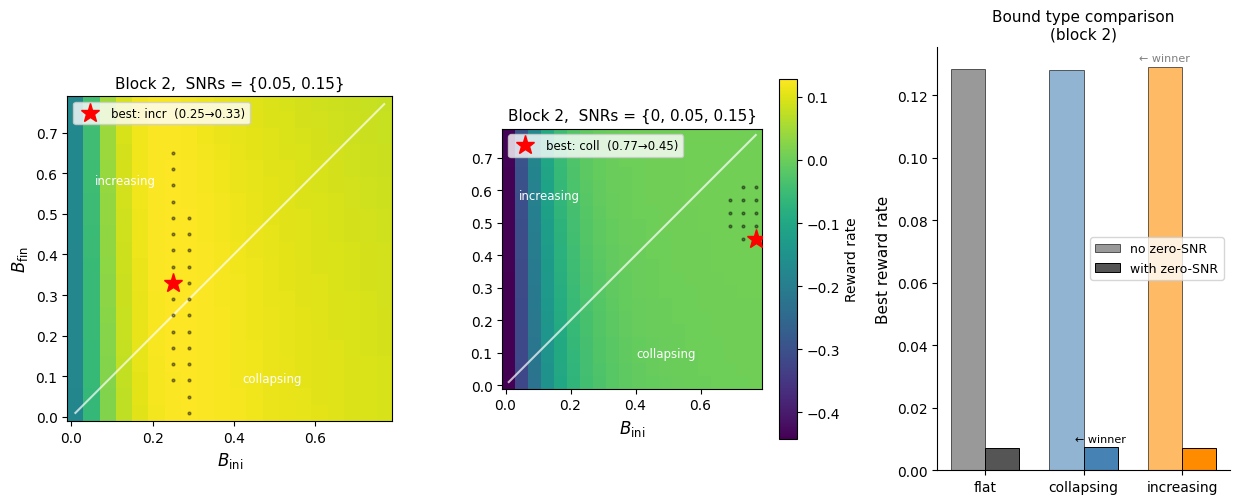

In [12]:
print("Computing RR matrix: {μ=0, μ=0.05, μ=0.15}, block 2…")
rm_zero = compute_rr_matrix([0.0, 0.05, 0.15])
flat_z, coll_z, incr_z, b_flat_z, Bi_z, Bf_z, kind_z = summarise(rm_zero)

print(f"\n  flat opt:  RR = {flat_z:.5f}  (b = {b_flat_z:.2f})")
print(f"  coll best: RR = {coll_z:.5f}  Δ = {coll_z-flat_z:+.5f}")
print(f"  incr best: RR = {incr_z:.5f}  Δ = {incr_z-flat_z:+.5f}")
print(f"  global best: {kind_z}  B_ini={Bi_z:.2f} → B_fin={Bf_z:.2f}")

fig = plt.figure(figsize=(15, 5.5))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.9], wspace=0.35)

half = (RR_BOUNDS[1] - RR_BOUNDS[0]) / 2
extent = [RR_BOUNDS[0]-half, RR_BOUNDS[-1]+half,
          RR_BOUNDS[0]-half, RR_BOUNDS[-1]+half]

# Use a shared colour scale so the two heatmaps are directly comparable
vmin = min(rm_nozero.min(), rm_zero.min())
vmax = max(rm_nozero.max(), rm_zero.max())

# ── Heatmap loop: one panel per SNR condition ─────────────────────────────────
# kind/Bi/Bf from the no-zero-SNR summarise() call are in scope from the previous cell.
for col, (rm, title, k, Bi, Bf) in enumerate([
        (rm_nozero, 'Block 2,  SNRs = {0.05, 0.15}',       kind,   Bi,   Bf),
        (rm_zero,   'Block 2,  SNRs = {0, 0.05, 0.15}',    kind_z, Bi_z, Bf_z)]):
    ax = fig.add_subplot(gs[col])
    im = ax.imshow(rm, origin='lower', extent=extent, aspect='equal',
                   cmap='viridis', vmin=vmin, vmax=vmax)

    # White diagonal = flat bound
    ax.plot([RR_BOUNDS[0], RR_BOUNDS[-1]], [RR_BOUNDS[0], RR_BOUNDS[-1]],
            'w-', lw=1.5, alpha=0.7)

    # Near-optimal region (within 2% of max)
    near = rm >= 0.98 * rm.max()
    fi2, ii2 = np.where(near)
    ax.plot(RR_BOUNDS[ii2], RR_BOUNDS[fi2], 'k.', ms=4, alpha=0.4)

    # Global optimum star
    bf2, bi2 = np.unravel_index(rm.argmax(), rm.shape)
    ax.plot(RR_BOUNDS[bi2], RR_BOUNDS[bf2], 'r*', ms=14, zorder=5,
            label=f'best: {k}  ({Bi:.2f}→{Bf:.2f})')

    ax.text(0.63, 0.12, 'collapsing', transform=ax.transAxes,
            color='white', fontsize=8.5, ha='center')
    ax.text(0.18, 0.73, 'increasing', transform=ax.transAxes,
            color='white', fontsize=8.5, ha='center')
    ax.set_xlabel('$B_\\mathrm{ini}$', fontsize=12)
    if col == 0:
        ax.set_ylabel('$B_\\mathrm{fin}$', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8.5, loc='upper left')

plt.colorbar(im, ax=fig.axes[1], label='Reward rate', shrink=0.85)

# ── Bar chart: best RR by bound type, with vs. without zero-SNR ──────────────
ax3 = fig.add_subplot(gs[2])

# Extract best flat/coll/incr for the no-zero-SNR condition
flat_nz = max(rm_nozero[i, i] for i in range(n))
coll_nz = rm_nozero[COLL_MASK].max()
incr_nz = rm_nozero[INCR_MASK].max()

categories  = ['flat', 'collapsing', 'increasing']
vals_nozero = [flat_nz, coll_nz, incr_nz]
vals_zero   = [flat_z,  coll_z,  incr_z]

x_pos = np.arange(3)
w = 0.35
ax3.bar(x_pos - w/2, vals_nozero, w, color=['#555', 'steelblue', 'darkorange'],
        alpha=0.6, label='no zero-SNR', edgecolor='k', linewidth=0.7)
ax3.bar(x_pos + w/2, vals_zero,   w, color=['#555', 'steelblue', 'darkorange'],
        alpha=1.0, label='with zero-SNR', edgecolor='k', linewidth=0.7)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(categories, fontsize=10)
ax3.set_ylabel('Best reward rate', fontsize=11)
ax3.set_title('Bound type comparison\n(block 2)', fontsize=11)
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# Annotate the winning bar in each condition
best_nz_val = max(vals_nozero)
best_z_val  = max(vals_zero)
ax3.annotate('← winner', xy=(x_pos[np.argmax(vals_nozero)] - w/2, best_nz_val),
             xytext=(0, 4), textcoords='offset points', fontsize=8, color='gray', ha='center')
ax3.annotate('← winner', xy=(x_pos[np.argmax(vals_zero)]   + w/2, best_z_val),
             xytext=(0, 4), textcoords='offset points', fontsize=8, color='black', ha='center')

plt.tight_layout()
plt.show()

---
## Take-away

| Condition | Optimal bound | Why |
|---|---|---|
| {μ=0.05, μ=0.15}, block 2 | **Increasing** | b*(lo) > b*(hi); hard trials need more evidence; surviving pool enriches toward lo-SNR over time → bound should rise |
| {μ=0, μ=0.05, μ=0.15}, block 2 | **Collapsing** | μ=0 trials are the last survivors; continued accumulation is worthless; bound should collapse to commit quickly |

The Drugowitsch (2012) result is correct but implicitly assumes a prior with mass near μ=0.
For strictly non-zero SNR distributions (as in the pigeon MX task), the collapsing advantage
disappears.  This is not stated explicitly in that paper — it is a gap relative to the
questions raised by the pigeon task analysis.

---
## Part 3 — Optimal bound as a function of SNR

The earlier analysis showed that b*(lo) > b*(hi) for the two pigeon-task SNR values.
What does b*(μ) look like across the full SNR range?

The simulation reveals **two distinct regimes**, separated by the SNR at which block 2
becomes profitable:

**Profitable regime (μ ≳ 0.018):** b*(μ) decreases monotonically as μ increases.
Stronger drift means shorter walks are sufficient to reach the required accuracy, so a
smaller bound suffices.  Both pigeon-task SNRs sit here: b*(0.05) ≈ 0.45–0.55,
b*(0.15) ≈ 0.15–0.19.

**Unprofitable regime (μ ≲ 0.018):** At very low SNR, no flat bound can achieve the 80%
accuracy needed to earn positive expected reward.  The best strategy is not to respond
quickly (which would maximise the *number* of losses per unit time), but to respond as
*slowly* as possible to minimise the *rate* of losses.  Consequently b* is pinned at the
grid maximum — the RR(b) curve is monotonically increasing, so the argmax is always the
largest bound.

Note that the profitability zero-crossing is at μ ≈ 0.018, **much lower** than the
first-step break-even threshold Φ(μ/σ) = 0.80 (μ ≈ 0.126).  That threshold marks when a
*single step* is profitable; with up to 300 steps, evidence accumulation makes even small μ
profitable.

A non-monotone peak (b* rising then falling as μ decreases) would only appear if the bound
grid extended to values large enough that the 300-step timeout starts constraining
performance, which is well above the b = 0.81 ceiling used here.

SNR is sampled in **log space** to adequately cover both regimes.

In [ ]:
from scipy.stats import norm as scipy_norm

# ── SNR sweep parameters ──────────────────────────────────────────────────────
# Log-spaced μ values spanning ~3 orders of magnitude.
# Lower end captures the "not profitable at any bound" regime.
# Upper end captures the "easy, small bound suffices" regime.
MU_SCAN = np.logspace(np.log10(0.003), np.log10(0.40), 35)

# Finer bound grid than the RR-matrix simulations — needed to resolve the b* peak.
B_SCAN = np.arange(0.01, 0.82, 0.02)   # 41 values

N_SCAN    = 40_000   # trials per μ value
MAX_SCAN  = 300      # per-trial step limit (same as main simulations)
rng_scan  = np.random.default_rng(7)

print(f"Scanning {len(MU_SCAN)} μ values × {len(B_SCAN)} bounds = "
      f"{len(MU_SCAN)*len(B_SCAN):,} evaluations")
print(f"μ range: {MU_SCAN[0]:.4f} – {MU_SCAN[-1]:.3f}  (log-spaced)")

b_star  = []   # optimal flat bound for each μ
rr_star = []   # reward rate at that optimal bound
rr_curves = [] # full RR(b) curve for each μ (kept for plotting a selection)

for mu in MU_SCAN:
    # Generate fresh trajectories for this μ value
    noise = rng_scan.normal(mu, G_STD, (N_SCAN, MAX_SCAN))
    DV  = np.concatenate([np.zeros((N_SCAN, 1)),
                           np.cumsum(noise, axis=1)], axis=1).astype(np.float32)
    ndt = rng_scan.integers(0, 2, N_SCAN)

    rr_at_b = []
    for b in B_SCAN:
        crossed = np.abs(DV[:, 1:]) >= b
        any_c   = crossed.any(axis=1)
        si      = np.where(any_c, np.argmax(crossed, axis=1) + 1, MAX_SCAN)
        correct = DV[np.arange(N_SCAN), si] > 0
        coins   = np.where(correct, BD2['coins_gained'], -BD2['coins_lost'])
        # +1 matches simulate_trials convention: RT = si + ndt + 1
        rr_at_b.append(coins.sum() / (si + ndt + 1).sum())

    rr_at_b = np.array(rr_at_b)
    rr_curves.append(rr_at_b)
    best_idx = np.argmax(rr_at_b)
    b_star.append(B_SCAN[best_idx])
    rr_star.append(rr_at_b[best_idx])
    print(f"  μ={mu:.4f}  b*={B_SCAN[best_idx]:.3f}  RR*={rr_at_b[best_idx]:+.5f}", end='\r')

b_star  = np.array(b_star)
rr_star = np.array(rr_star)
print(f"\nDone. Peak b* = {b_star.max():.3f} at μ = {MU_SCAN[b_star.argmax()]:.4f}")

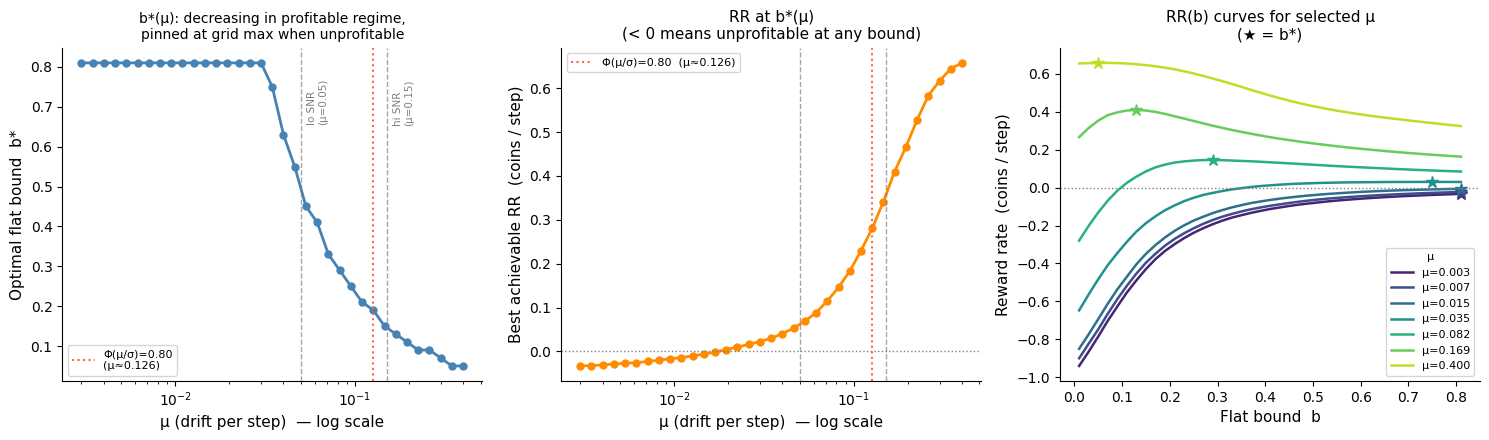

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# μ at which Φ(μ/σ) = 0.80 — the discrete-walk break-even threshold.
# Below this value, even responding immediately gives < 80% accuracy.
mu_breakeven = scipy_norm.ppf(0.80) * G_STD   # ≈ 0.126

# ── Panel 1: b*(μ) vs μ ──────────────────────────────────────────────────────
ax = axes[0]
ax.semilogx(MU_SCAN, b_star, 'o-', color='steelblue', lw=2, ms=5)

# Vertical dashed lines for the two pigeon-task SNR levels
for mu_pt, label in [(0.05, 'lo SNR\n(μ=0.05)'), (0.15, 'hi SNR\n(μ=0.15)')]:
    ax.axvline(mu_pt, color='gray', ls='--', lw=1, alpha=0.7)
    ax.text(mu_pt * 1.08, b_star.max() * 0.95, label,
            fontsize=7.5, color='gray', rotation=90, va='top')

# Discrete-walk break-even: μ where first-step accuracy = 0.80
ax.axvline(mu_breakeven, color='tomato', ls=':', lw=1.5,
           label=f'Φ(μ/σ)=0.80\n(μ≈{mu_breakeven:.3f})')
ax.set_xlabel('μ (drift per step)  — log scale', fontsize=11)
ax.set_ylabel('Optimal flat bound  b*', fontsize=11)
ax.set_title('b*(μ): decreasing in profitable regime,\npinned at grid max when unprofitable', fontsize=10)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: RR*(μ) — best achievable reward rate at b*(μ) ───────────────────
ax = axes[1]
ax.semilogx(MU_SCAN, rr_star, 'o-', color='darkorange', lw=2, ms=5)
ax.axhline(0, color='gray', ls=':', lw=1)   # RR=0 = break-even for the whole session
ax.axvline(mu_breakeven, color='tomato', ls=':', lw=1.5,
           label=f'Φ(μ/σ)=0.80  (μ≈{mu_breakeven:.3f})')
for mu_pt in [0.05, 0.15]:
    ax.axvline(mu_pt, color='gray', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('μ (drift per step)  — log scale', fontsize=11)
ax.set_ylabel('Best achievable RR  (coins / step)', fontsize=11)
ax.set_title('RR at b*(μ)\n(< 0 means unprofitable at any bound)', fontsize=11)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 3: RR(b) curves for a selection of μ values ────────────────────────
# Illustrates how the shape (and the location of b*) evolves across SNR levels.
# Low μ: curve is monotonically increasing → b* at grid max.
# High μ: hump-shaped curve with interior optimum shifting left as μ rises.
ax = axes[2]
show_idxs = np.round(np.linspace(0, len(MU_SCAN)-1, 7)).astype(int)
colors_scan = plt.cm.viridis(np.linspace(0.1, 0.9, len(show_idxs)))

for idx, color in zip(show_idxs, colors_scan):
    mu_show = MU_SCAN[idx]
    ax.plot(B_SCAN, rr_curves[idx], color=color, lw=1.8, label=f'μ={mu_show:.3f}')
    best = np.argmax(rr_curves[idx])   # index of b*
    ax.plot(B_SCAN[best], rr_curves[idx][best], '*', color=color, ms=9)

ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Flat bound  b', fontsize=11)
ax.set_ylabel('Reward rate  (coins / step)', fontsize=11)
ax.set_title('RR(b) curves for selected μ\n(★ = b*)', fontsize=11)
ax.legend(fontsize=8, title='μ', title_fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()